In [1]:
# ============================================
# SENTIMENT AND TOPIC ANALYSIS PROJECT
# ============================================

# ============================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ============================================

import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import LinearSVC
from gensim import corpora
from gensim.models import LdaModel
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# ============================================
# STEP 2: DOWNLOAD REQUIRED NLP RESOURCES
# ============================================

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Gokoy\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Gokoy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Gokoy\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [3]:
# ============================================
# STEP 3: LOAD DATASET
# ============================================

df = pd.read_csv("Twitter Climate Change Sentiment Dataset_twitter_sentiment_data.csv")
print(df.head())
print("Dataset shape:", df.shape)
print("Columns:", df.columns)

   sentiment                                            message  \
0         -1  @tiniebeany climate change is an interesting h...   
1          1  RT @NatGeoChannel: Watch #BeforeTheFlood right...   
2          1  Fabulous! Leonardo #DiCaprio's film on #climat...   
3          1  RT @Mick_Fanning: Just watched this amazing do...   
4          2  RT @cnalive: Pranita Biswasi, a Lutheran from ...   

              tweetid  
0  792927353886371840  
1  793124211518832641  
2  793124402388832256  
3  793124635873275904  
4  793125156185137153  
Dataset shape: (43943, 3)
Columns: Index(['sentiment', 'message', 'tweetid'], dtype='object')


In [4]:
# ============================================
# STEP 4: DATA QUALITY ASSESSMENT
# ============================================

print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate tweets:", df.duplicated(subset=['message']).sum())

sentiment    0
message      0
tweetid      0
dtype: int64
Duplicate rows: 0
Duplicate tweets: 2910


In [5]:
# ============================================
# STEP 5: TO DELETE DUPLICATE TWEETS
# ============================================

# i: Show duplicate tweets
duplicate_tweets = df[df.duplicated(subset=['message'], keep=False)]

print("Duplicate Tweets (Before Removal):")
print(duplicate_tweets[['message']].head(10))  # show sample

print("\nTotal duplicate tweets:", df.duplicated(subset=['message']).sum())

Duplicate Tweets (Before Removal):
                                              message
1   RT @NatGeoChannel: Watch #BeforeTheFlood right...
4   RT @cnalive: Pranita Biswasi, a Lutheran from ...
6   RT @cnalive: Pranita Biswasi, a Lutheran from ...
12  RT @NatGeoChannel: Watch #BeforeTheFlood right...
14  RT @WorldResources: Reflections on Leonardo Di...
16  RT @NatGeoChannel: One of the easiest ways to ...
18  RT @ClimateCentral: Here's how climate change ...
19  RT @NatGeoChannel: Watch #BeforeTheFlood right...
26  RT @NatGeoChannel: Watch #BeforeTheFlood right...
29  RT @NatGeoChannel: Watch #BeforeTheFlood right...

Total duplicate tweets: 2910


In [6]:
# ii: Remove duplicate tweets
df = df.drop_duplicates(subset=['message'])

In [7]:
# iii: Verify duplicates are removed
print("\nAfter Removal:")
print("Remaining duplicate tweets:", df.duplicated(subset=['message']).sum())

print("Updated dataset shape:", df.shape)


After Removal:
Remaining duplicate tweets: 0
Updated dataset shape: (41033, 3)


In [8]:
# ============================================
# STEP 5: TEXT CLEANING
# ============================================
# i This gives us a summary of how dirty our data is:

print("URLs:", df['message'].str.contains(r'http\S+', regex=True).sum())
print("Mentions:", df['message'].str.contains(r'@\w+', regex=True).sum())
print("Hashtags:", df['message'].str.contains(r'#', regex=True).sum())
print("RT:", df['message'].str.contains(r'\brt\b', case=False, regex=True).sum())
#print("extra spaces:", df['message'].str.contains(r' ', regex=True).sum())
print("Special chars:", df['message'].str.contains(r'[^a-zA-Z\s]', regex=True).sum())

URLs: 24662
Mentions: 28272
Hashtags: 7928
RT: 22247
Special chars: 40771


In [9]:
# ii Clean the data
def clean_text(text):
    text = str(text).lower()  # Convert to lowercase
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'@\w+', '', text)     # Remove mentions
    text = re.sub(r'#\w+', '', text)     # Remove hashtags
    text = re.sub(r'[^a-z\s]', '', text) # Remove special characters
    return text
df['clean_text'] = df['message'].apply(clean_text)
df[['message', 'clean_text']].head()

,message,clean_text
0,@tiniebeany climate change is an interesting h...,climate change is an interesting hustle as it...
1,RT @NatGeoChannel: Watch #BeforeTheFlood right...,rt watch right here as travels the world to...
2,Fabulous! Leonardo #DiCaprio's film on #climat...,fabulous leonardo s film on change is brillia...
3,RT @Mick_Fanning: Just watched this amazing do...,rt just watched this amazing documentary by l...
4,"RT @cnalive: Pranita Biswasi, a Lutheran from ...",rt pranita biswasi a lutheran from odisha giv...


In [10]:
# ============================================
# STEP 6: FILTER SUSTAINABILITY TWEETS
# ============================================
# To define keywords related to environmental topics and filter the dataset to include only rows where the cleaned text contains any of these keywords
keywords = ['eco', 'sustainable', 'green', 'climate']
df_filtered = df[df['clean_text'].str.contains('|'.join(keywords), case=False, na=False)]
print(df_filtered)

       sentiment                                            message  \
0             -1  @tiniebeany climate change is an interesting h...   
1              1  RT @NatGeoChannel: Watch #BeforeTheFlood right...   
3              1  RT @Mick_Fanning: Just watched this amazing do...   
4              2  RT @cnalive: Pranita Biswasi, a Lutheran from ...   
7              2  RT @CCIRiviera: Presidential Candidate #Donald...   
...          ...                                                ...   
43937          2  RT @cnni: Leonardo DiCaprio: $q$Not one questi...   
43938          1  Dear @realDonaldTrump,\nYeah right. Human Medi...   
43939          1  What will your respective parties do to preven...   
43940          2  RT @MikkiL: UN Poll Shows Climate Change Is th...   
43942          1  @Likeabat77 @zachhaller \n\nThe wealthy + foss...   

                  tweetid                                         clean_text  
0      792927353886371840   climate change is an interesting hustle 

In [11]:
# ii Define sustainability-related keywords
keywords = ['eco', 'sustainable', 'green', 'climate']
df_filtered = df[df['clean_text'].str.contains('|'.join(keywords), case=False)]
print("Filtered dataset size:", df_filtered.shape)

Filtered dataset size: (31336, 4)


In [12]:
# ============================================
# STEP 7: TOKENIZATION AND STOPWORD REMOVAL
# ============================================
# Define stopwords
stop_words = set(stopwords.words('english'))

# Function for tokenization and stopword removal
def preprocess(text):
    tokens = word_tokenize(text)  # Split text into words
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    return tokens

# Apply preprocessing
df_filtered['tokens'] = df_filtered['clean_text'].apply(preprocess)

# Preview tokens
df_filtered[['clean_text', 'tokens']].head(10)

C:\Users\Gokoy\AppData\Local\Temp\ipykernel_10640\726771205.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['tokens'] = df_filtered['clean_text'].apply(preprocess)


,clean_text,tokens
0,climate change is an interesting hustle as it...,"[climate, change, interesting, hustle, global,..."
1,rt watch right here as travels the world to...,"[rt, watch, right, travels, world, tackle, cli..."
3,rt just watched this amazing documentary by l...,"[rt, watched, amazing, documentary, leonardodi..."
4,rt pranita biswasi a lutheran from odisha giv...,"[rt, pranita, biswasi, lutheran, odisha, gives..."
7,rt presidential candidate is dangerous on cl...,"[rt, presidential, candidate, dangerous, clima..."
8,rt leonardo dicaprios climate change document...,"[rt, leonardo, dicaprios, climate, change, doc..."
9,watch right here as travels the world to ta...,"[watch, right, travels, world, tackle, climate..."
10,rt its vital that the public health community...,"[rt, vital, public, health, community, address..."
11,bangladesh did not cause climate change so the...,"[bangladesh, cause, climate, change, country, ..."
13,nows the time we need a strong that works for...,"[nows, time, need, strong, works, hardest, hit..."


In [13]:
# ============================================
# STEP 8: SENTIMENT ANALYSIS (VADER)
# ============================================

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df_filtered['vader_sentiment'] = df_filtered['clean_text'].apply(get_sentiment)
print(df_filtered[['clean_text', 'vader_sentiment']].head(10))

                                           clean_text vader_sentiment
0    climate change is an interesting hustle as it...        Positive
1   rt  watch  right here as  travels the world to...         Neutral
3   rt  just watched this amazing documentary by l...        Positive
4   rt  pranita biswasi a lutheran from odisha giv...        Negative
7   rt  presidential candidate  is dangerous on cl...        Negative
8   rt  leonardo dicaprios climate change document...        Positive
9    watch  right here as  travels the world to ta...         Neutral
10  rt  its vital that the public health community...        Positive
11  bangladesh did not cause climate change so the...         Neutral
13  nows the time we need a strong  that works for...         Neutral


C:\Users\Gokoy\AppData\Local\Temp\ipykernel_10640\2168362446.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['vader_sentiment'] = df_filtered['clean_text'].apply(get_sentiment)


In [14]:
# ============================================
# STEP 9: TF-IDF FEATURE EXTRACTION
# ============================================
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df_filtered['clean_text'])
y = df_filtered['sentiment']
print("TF-IDF Vectorization:", df_filtered)

TF-IDF Vectorization:        sentiment                                            message  \
0             -1  @tiniebeany climate change is an interesting h...   
1              1  RT @NatGeoChannel: Watch #BeforeTheFlood right...   
3              1  RT @Mick_Fanning: Just watched this amazing do...   
4              2  RT @cnalive: Pranita Biswasi, a Lutheran from ...   
7              2  RT @CCIRiviera: Presidential Candidate #Donald...   
...          ...                                                ...   
43937          2  RT @cnni: Leonardo DiCaprio: $q$Not one questi...   
43938          1  Dear @realDonaldTrump,\nYeah right. Human Medi...   
43939          1  What will your respective parties do to preven...   
43940          2  RT @MikkiL: UN Poll Shows Climate Change Is th...   
43942          1  @Likeabat77 @zachhaller \n\nThe wealthy + foss...   

                  tweetid                                         clean_text  \
0      792927353886371840   climate change is

In [15]:
#==================================
#STEP 10: TRAIN NAÏVE BAYES MODEL
#==================================
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train model
model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)

# Make predictions
y_pred = model_nb.predict(X_test)

# Evaluate model
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Naive Bayes Accuracy: 0.6740587109125717
              precision    recall  f1-score   support

          -1       0.81      0.05      0.09       450
           0       0.60      0.05      0.09       844
           1       0.65      0.94      0.77      3433
           2       0.77      0.60      0.67      1541

    accuracy                           0.67      6268
   macro avg       0.71      0.41      0.41      6268
weighted avg       0.68      0.67      0.61      6268



In [16]:
#==================================
# ii TRAIN NAÏVE BAYES MODEL
#==================================

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 1: Define features (X) and target (y)
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df_filtered['clean_text'])

y = df_filtered['vader_sentiment']

# Step 2: Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Train model
model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)

# Step 4: Predict
y_pred = model_nb.predict(X_test)

# Step 5: Evaluate
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Naive Bayes Accuracy: 0.6841097638800255
              precision    recall  f1-score   support

    Negative       0.60      0.92      0.73      2477
     Neutral       0.89      0.41      0.56      1747
    Positive       0.77      0.63      0.69      2044

    accuracy                           0.68      6268
   macro avg       0.75      0.65      0.66      6268
weighted avg       0.74      0.68      0.67      6268



In [17]:
#=======================================
#STEP 11: TRAIN SVM MODEL (OPTIONAL)
#=======================================
# Initialize and train SVM model
model_svm = LinearSVC()
model_svm.fit(X_train, y_train)

# Make predictions
y_pred_svm = model_svm.predict(X_test)

# Evaluate model
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

C:\Users\Gokoy\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


SVM Accuracy: 0.8664645820038289


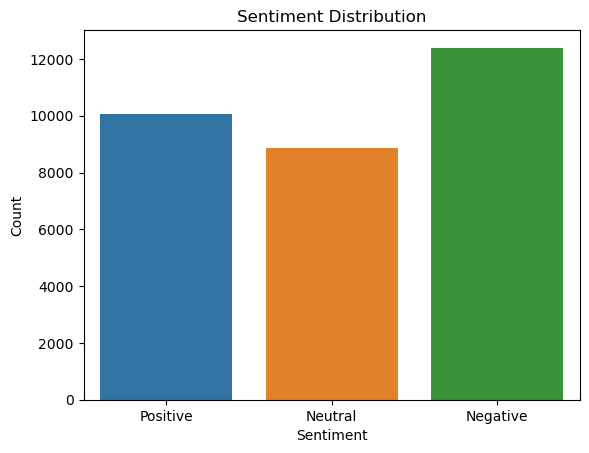

In [18]:
# ============================================
# STEP 13: SENTIMENT VISUALIZATION
# ============================================
# VISUALISATION 1
sns.countplot(x='vader_sentiment', data=df_filtered)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [19]:
#Import wordcloud library
!pip install wordcloud

In [20]:
#Test Installation

from wordcloud import WordCloud
print("WordCloud installed successfully!")

WordCloud installed successfully!


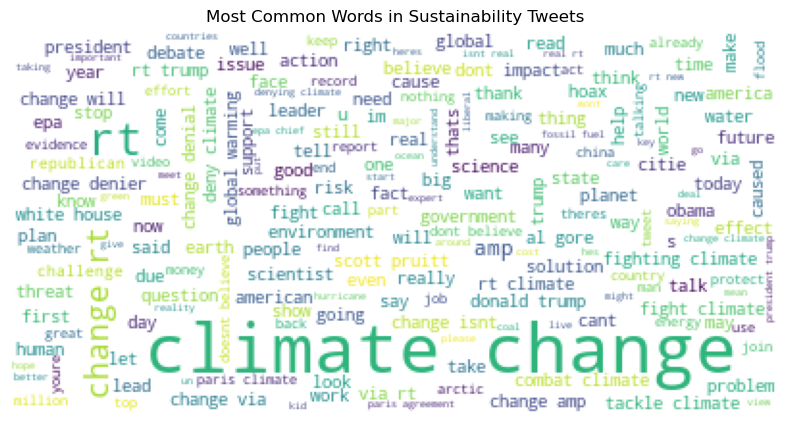

In [21]:
#VISUALUSATION 2
# Word Cloud Visualization: Display Most Frequent Words in Sustainability Tweets

from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df_filtered['clean_text'])

wordcloud = WordCloud(background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Most Common Words in Sustainability Tweets")

plt.show()

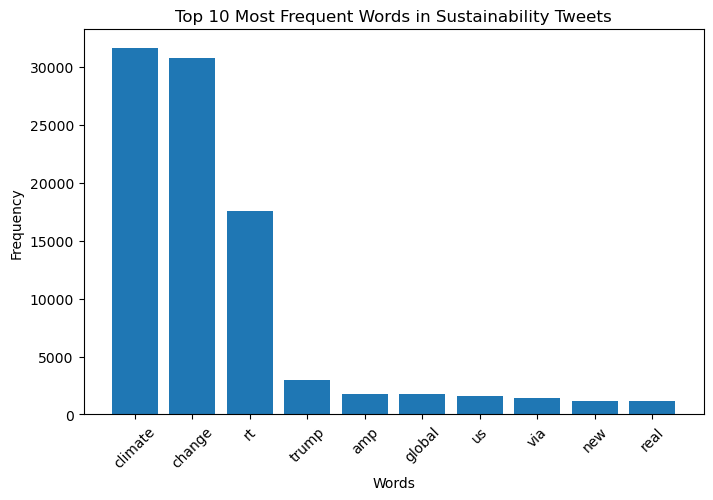

In [22]:
# VISUALUSATION 3 (TOP WORDS BAR CHART)
# Word Frequency Analysis: Visualizing Top 10 Most Frequent Words in Filtered Tweets

from collections import Counter
import matplotlib.pyplot as plt

# Flatten list of tokens into a single list of words
all_words = [word for tokens in df_filtered['tokens'] for word in tokens]

# Count word frequencies and get top 10
word_counts = Counter(all_words).most_common(10)

# Separate words and their counts
words = [w[0] for w in word_counts]
counts = [w[1] for w in word_counts]

# Plot bar chart
plt.figure(figsize=(8,5))
plt.bar(words, counts)

plt.title("Top 10 Most Frequent Words in Sustainability Tweets")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)
plt.show()

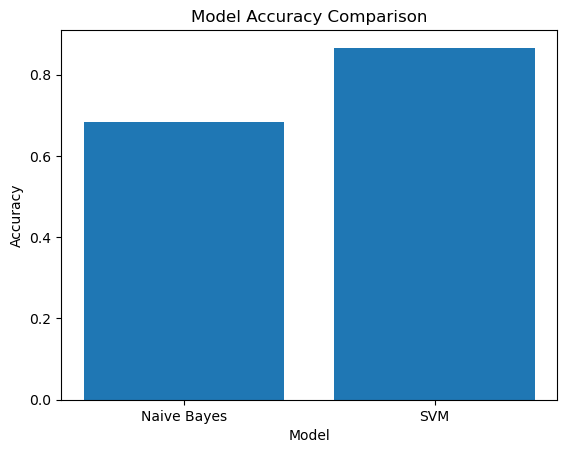

In [23]:
# MODEL COMPARISON
#VISUALISATION 4
models = ['Naive Bayes', 'SVM']
accuracy = [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_svm)]

plt.figure()
plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.show()

In [24]:
#VISUALISATION 5
from gensim import corpora
from gensim.models import LdaModel

# Prepare text data
texts = df_filtered['tokens'].tolist()

# Create dictionary
dictionary = corpora.Dictionary(texts)

# Create corpus
corpus = [dictionary.doc2bow(text) for text in texts]

# Train LDA model
lda_model = LdaModel(
    corpus=corpus,
    num_topics=5,
    id2word=dictionary,
    passes=10,
    random_state=42
)

In [25]:
# Get topic labels (keywords)
# Extract top keywords for each topic
topic_labels = {}

for i in range(5):
    words = [word for word, prob in lda_model.show_topic(i, topn=3)]
    topic_labels[i] = ", ".join(words)
    print(topic_labels)

{0: 'climate, change, rt'}
{0: 'climate, change, rt', 1: 'climate, change, rt'}
{0: 'climate, change, rt', 1: 'climate, change, rt', 2: 'climate, change, rt'}
{0: 'climate, change, rt', 1: 'climate, change, rt', 2: 'climate, change, rt', 3: 'climate, change, rt'}
{0: 'climate, change, rt', 1: 'climate, change, rt', 2: 'climate, change, rt', 3: 'climate, change, rt', 4: 'climate, change, rt'}


In [26]:
# Count dominant topics
# Count dominant topic per document
topic_counts = []

for doc in corpus:
    topics = lda_model.get_document_topics(doc)
    topic_counts.append(max(topics, key=lambda x: x[1])[0])
    #print(topic_counts)

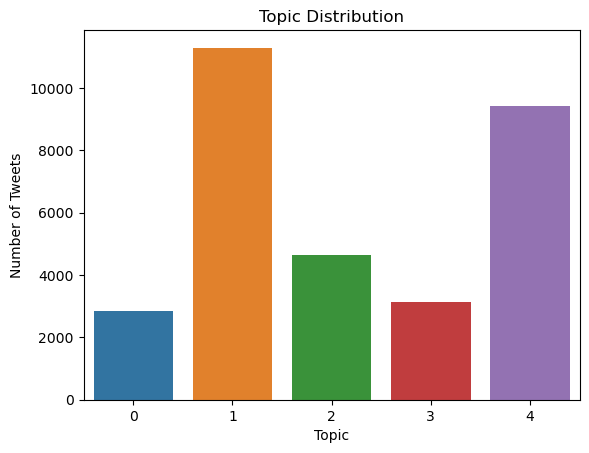

In [27]:
#TOPIC DISTRIBUTION (LDA)
# Count dominant topics
topic_counts = []

for doc in corpus:
    topics = lda_model.get_document_topics(doc)
    topic_counts.append(max(topics, key=lambda x: x[1])[0])

plt.figure()
sns.countplot(x=topic_counts)

plt.title("Topic Distribution")
plt.xlabel("Topic")
plt.ylabel("Number of Tweets")

plt.show()

In [28]:
# Extract top words per topic
topic_labels = {}

for i in range(lda_model.num_topics):
    words = lda_model.show_topic(i, topn=5)
    topic_labels[i] = ", ".join([word for word, prob in words])

print(topic_labels)

{0: 'climate, change, rt, oil, amp', 1: 'climate, change, rt, amp, global', 2: 'climate, change, rt, action, take', 3: 'climate, change, rt, trump, energy', 4: 'climate, change, rt, real, trump'}


In [29]:
# Replace topic IDs with labels
topic_names = [topic_labels[t] for t in topic_counts]

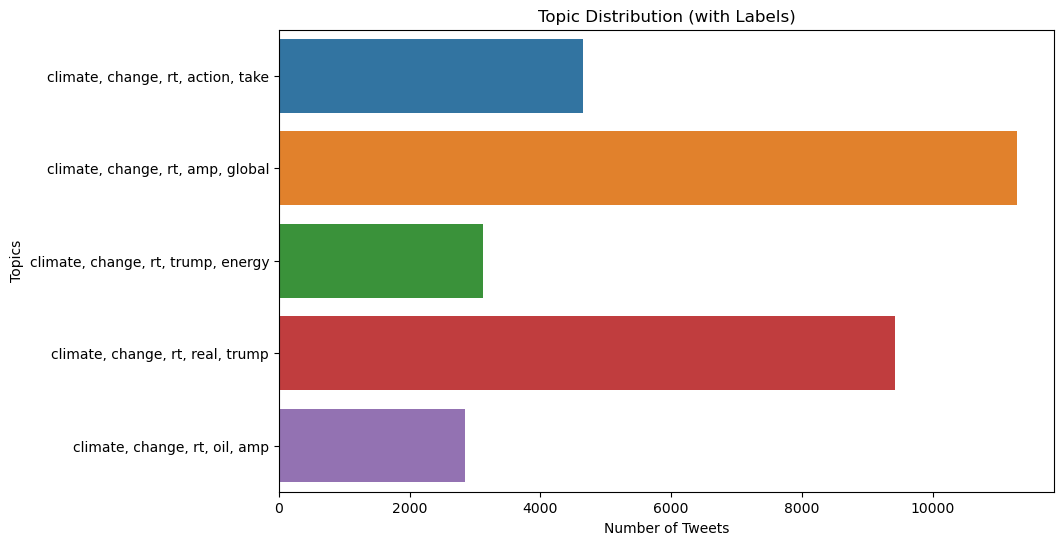

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(y=topic_names)   # 👈 use y instead of x for better readability

plt.title("Topic Distribution (with Labels)")
plt.xlabel("Number of Tweets")
plt.ylabel("Topics")

plt.show()